# NOTEBOOK 02 — Signal Construction

---

## Theoretical Background

This notebook implements the **cross-sectional momentum signal** first documented by  
**Jegadeesh & Titman (1993)** in:

> *"Returns to Buying Winners and Selling Losers: Implications for Stock Market Efficiency"*  
> *(Journal of Finance, Vol. 48, No. 1, pp. 65–91)*

---

## Core Hypothesis

Stocks that have **outperformed their peers over the past 12 months** tend to  
**continue outperforming over the next 1–3 months**.

This phenomenon is known as the **momentum effect** — one of the most robust  
and well-documented anomalies in empirical asset pricing.

---

## The Signal: 12–1 Momentum

For each stock $i$ at time $t$, the momentum signal is defined as:

$$\text{MOM}(i,t) = \frac{P(i,\ t-21)}{P(i,\ t-252)} - 1$$

| Symbol | Meaning |
|---|---|
| $P(i, t)$ | Adjusted closing price of stock $i$ at time $t$ |
| $t - 252$ | Approximately **12 months ago** (252 trading days per year) |
| $t - 21$ | Approximately **1 month ago** (21 trading days per month) |

---

## Why Skip the Last Month?

The most recent month (from $t-21$ to $t$) is deliberately excluded from the formation window.  
This is standard practice in the momentum literature for two reasons:

**1. Short-Term Reversal**  
At horizons shorter than one month, stock returns tend to *reverse* rather than continue,  
due to microstructure effects such as bid-ask bounce and liquidity-driven price pressure.  
Including this period would introduce noise that works against the momentum signal.

**2. Lookahead Bias Prevention**  
Excluding the last month creates a clean separation between the *signal formation period*  
and the *holding period*, ensuring no information leakage from future prices into the signal.

---

## Signal Interpretation

At each date $t$, all stocks are ranked by their MOM score cross-sectionally:

| MOM Score | Interpretation | Portfolio Role |
|---|---|---|
| Top 20% | Recent outperformers — **Winners** | **LONG** |
| Middle 60% | Neutral | Excluded |
| Bottom 20% | Recent underperformers — **Losers** | **SHORT** |

---

## Key Insight: Cross-Sectional vs. Time-Series

This signal is **cross-sectional** — it does not predict the direction of the overall market.  
It identifies *which stocks* will outperform or underperform *relative to their peers*  
at each point in time. This makes the resulting long-short portfolio approximately  
**market-neutral by construction**.

---

## Important Methodological Note

As documented in Jegadeesh & Titman (1993), momentum returns are **not explained  
by systematic risk (beta)**. The authors explicitly test this using CAPM and find  
that the strategy generates significant *alpha* after controlling for market exposure.  
We will replicate this risk decomposition in **Notebook 05 — Risk Analysis**.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Load cleaned price data from notebook 01
prices = pd.read_parquet('../data/sp500_prices.parquet')

print("=== DATA LOADED ===")
print(f"Shape:       {prices.shape}")
print(f"Start date:  {prices.index[0].date()}")
print(f"End date:    {prices.index[-1].date()}")
print(f"Tickers:     {prices.shape[1]}")

=== DATA LOADED ===
Shape:       (3773, 449)
Start date:  2010-01-04
End date:    2024-12-30
Tickers:     449




## Step 1: Forward Fill Missing Values

### Theory

Our price matrix contains **NaN values** for two legitimate reasons:

1. **Company Not Yet Listed**  
   Some companies (e.g. ABBV) were spun off or listed after 2010.  
   Their prices are therefore **NaN before the IPO date**.

2. **Trading Halts**  
   Occasionally, a stock does not trade on a given day due to:
   - trading halts  
   - exchange holidays  

   In these cases, the price is effectively **unchanged**.

---

### Forward Fill (ffill)

**Forward fill** is the standard solution in quantitative finance:

> If a price is missing at time \( t \), we carry forward the **last available price**.

This approach is economically justified because the last traded price is the  
**best available estimate of fair value** on that day.

---

### Important Constraint

We apply a limit of **5 consecutive days** to the forward fill.

- If missing values persist for **≤ 5 days** → values are forward filled  
- If missing values persist for **> 5 days** → values remain **NaN**

This prevents **stale prices** from contaminating the signal.

In [43]:
prices_filled = prices.ffill(limit=5)

# Verify the effect of forward fill
nan_before = prices.isnull().sum().sum()
nan_after  = prices_filled.isnull().sum().sum()

print("=== FORWARD FILL RESULTS ===")
print(f"NaN values before ffill: {nan_before:,}")
print(f"NaN values after ffill:  {nan_after:,}")
print(f"NaN values filled:       {nan_before - nan_after:,}")

=== FORWARD FILL RESULTS ===
NaN values before ffill: 9,533
NaN values after ffill:  9,533
NaN values filled:       0


## Forward Fill — Notes

Zero NaN values were filled by the forward fill procedure. This indicates that
all 9,533 remaining NaN values are located at the **beginning of individual
time series** — i.e., companies that were listed or spun off after January 2010
(e.g., ABBV, which was spun off from ABT in January 2013). There are no
internal gaps in the price data, confirming the quality of the download.

The forward fill limit of 5 days was therefore not binding in this dataset.


## Train / Test Split

### Theory

To ensure an **honest evaluation** of the momentum signal, we strictly separate the dataset into two non-overlapping periods:

---

### In-Sample (2010–2018)

Used for:

- signal construction  
- Information Coefficient (IC) analysis  
- parameter selection  

All modelling decisions are made **exclusively on this period**.

---

### Out-of-Sample (2019–2024)

Used **only once at the end** (Notebook 05) to verify that the signal:

- generalizes beyond the training period  
- maintains performance in unseen data  

> Accessing or analyzing this period prematurely would introduce **lookahead bias at the research level**.

---

### Key Principle: Avoiding Overfitting

This separation is the **primary defense against overfitting** in quantitative research.

A signal that:

- works in-sample  
- fails out-of-sample  

is almost certainly **fit to historical noise rather than real structure**.

In [45]:
SPLIT_DATE = '2018-12-31'

prices_is  = prices_filled.loc[:SPLIT_DATE]   # in-sample
prices_oos = prices_filled.loc[SPLIT_DATE:]   # out-of-sample — locked

print("=== TRAIN / TEST SPLIT ===")
print(f"In-sample:      {prices_is.index[0].date()} → {prices_is.index[-1].date()}  ({len(prices_is)} days)")
print(f"Out-of-sample:  {prices_oos.index[0].date()} → {prices_oos.index[-1].date()}  ({len(prices_oos)} days)")
print(f"\nOut-of-sample data is now locked. It will not be used until notebook 05.")

=== TRAIN / TEST SPLIT ===
In-sample:      2010-01-04 → 2018-12-31  (2264 days)
Out-of-sample:  2018-12-31 → 2024-12-30  (1510 days)

Out-of-sample data is now locked. It will not be used until notebook 05.


## Train / Test Split — Methodology

The dataset is divided into two strictly non-overlapping periods:

| Period | Date Range | Trading Days |
|---|---|---|
| In-sample | 2010-01-04 → 2018-12-31 | 2,264 |
| Out-of-sample | 2018-12-31 → 2024-12-30 | 1,510 |

The in-sample period (≈ 9 years) is used exclusively for signal construction,
IC analysis, and backtesting. The out-of-sample period is **locked** and will
not be examined until Notebook 05.

This separation is the primary methodological safeguard against overfitting:
any signal that appears to work in-sample but fails out-of-sample is almost
certainly fitting historical noise rather than a structural market anomaly.


## Step 2: Compute Daily Returns

### Theory

We work with **returns** rather than raw prices for two fundamental reasons:

### 1. Stationarity

Raw prices are **non-stationary** — they tend to drift over time and do not have a natural mean.

Returns, defined as:

$$
r(i,t) = \frac{P(i,t)}{P(i,t-1)} - 1
$$

are approximately **stationary**, making them suitable for:
- statistical analysis  
- cross-sectional comparison  

---

### 2. Comparability

A \$10 price change has very different implications for:
- a \$20 stock  
- a \$500 stock  

Returns **normalize price changes**, allowing meaningful comparisons across assets.

---

## Note on Compounding

For momentum signal construction, we compute the **cumulative return** over the lookback window using compounding:

$$
\text{MOM}(i,t) = \prod_{s = t-252}^{t-21} (1 + r(i,s)) - 1
$$

This is equivalent to:

$$
\frac{P(i, t-21)}{P(i, t-252)} - 1
$$

and correctly accounts for the **compounding of daily returns** over the formation period.

In [47]:
# Daily simple returns
daily_returns = prices_is.pct_change()

print("=== DAILY RETURNS ===")
print(f"Shape: {daily_returns.shape}")
print(f"\nSample (AAPL, first 5 trading days):")
print(daily_returns['AAPL'].dropna().head())
print(f"\nDescriptive statistics (cross-sectional sample):")
print(daily_returns.iloc[:, :10].describe().round(4))

=== DAILY RETURNS ===
Shape: (2264, 449)

Sample (AAPL, first 5 trading days):
Date
2010-01-05    0.001729
2010-01-06   -0.015907
2010-01-07   -0.001848
2010-01-08    0.006648
2010-01-11   -0.008821
Name: AAPL, dtype: float64

Descriptive statistics (cross-sectional sample):
Ticker          A       AAPL       ABBV        ABT       ACGL        ACN  \
count   2263.0000  2263.0000  1509.0000  2263.0000  2263.0000  2263.0000   
mean       0.0007     0.0009     0.0009     0.0006     0.0006     0.0007   
std        0.0178     0.0162     0.0173     0.0117     0.0103     0.0136   
min       -0.1101    -0.1236    -0.1276    -0.0929    -0.0762    -0.1038   
25%       -0.0076    -0.0069    -0.0074    -0.0053    -0.0049    -0.0058   
50%        0.0007     0.0008     0.0014     0.0006     0.0007     0.0010   
75%        0.0100     0.0096     0.0095     0.0071     0.0062     0.0075   
max        0.1176     0.0887     0.1377     0.0650     0.0675     0.0799   

Ticker       ADBE        ADI        ADM

## Daily Returns — Interpretation

Returns are computed on the **in-sample period only** (2,264 trading days).
Key observations:

- **Mean daily return (~0.06–0.10%):** consistent with long-run S&P 500 equity
  returns of approximately 10% per year (0.10% × 252 ≈ 10%).

- **Daily standard deviation (~1.2–1.8%):** typical for individual large-cap
  equities. Annualized, this implies volatility of roughly 19–29%, consistent
  with historical single-stock volatility estimates.

- **ABBV count = 1,509 vs 2,263 for others:** AbbVie was spun off from Abbott
  in January 2013, so approximately 750 observations at the start of the
  in-sample period are correctly NaN.

- **No extreme outliers:** all min/max values are within ±20%, consistent with
  the data quality checks performed in Notebook 01.


## Step 3: Construct the 12–1 Momentum Signal

### Theory

The momentum signal is computed as a **rolling cumulative return** over the  
formation window:

\[
[t-252, \; t-21]
\]

At each date \( t \), for each stock \( i \):

$$
\text{MOM}(i,t) = \frac{P(i, t-21)}{P(i, t-252)} - 1
$$

---

### Alternative Implementation (Log Returns)

For numerical stability, the signal can also be computed using **log returns**:

$$
\log r(i,t) = \log\left(\frac{P(i,t)}{P(i,t-1)}\right)
$$

$$
\text{MOM}(i,t) = \exp\left(\sum_{s=t-251}^{t-21} \log r(i,s)\right) - 1
$$

This formulation is mathematically equivalent and correctly handles compounding.

> In this notebook, we use **price ratios** for clarity.

---

## Parameters

- **FORMATION\_LONG**  = 252 trading days ≈ **12 months** (start of lookback)  
- **FORMATION\_SHORT** = 21 trading days ≈ **1 month** (end of lookback, skipped)  

---

## Minimum Observations

To compute a valid momentum score, a stock must have at least:

- **MIN\_OBS = 200** non-NaN daily returns within the formation window  

Stocks with fewer observations:

- receive **NaN**
- are **excluded from the ranking** at that point in time

In [49]:
FORMATION_LONG  = 252   # ~12 months
FORMATION_SHORT =  21   # ~1 month (skip period)
MIN_OBS         = 200   # minimum valid observations

def compute_momentum(prices, formation_long, formation_short, min_obs):
    """
    Compute the 12-1 cross-sectional momentum signal.
    
    For each date t and stock i:
        MOM(i,t) = P(i, t - formation_short) / P(i, t - formation_long) - 1
    
    Parameters
    ----------
    prices         : pd.DataFrame, adjusted closing prices
    formation_long : int, lookback start in trading days (252 = 12 months)
    formation_short: int, skip period in trading days  (21 = 1 month)
    min_obs        : int, minimum non-NaN observations required
    
    Returns
    -------
    momentum : pd.DataFrame, same shape as prices, momentum scores
    """
    # Shift prices to align formation window
    price_long  = prices.shift(formation_long)   # price 12 months ago
    price_short = prices.shift(formation_short)  # price 1 month ago

    # Raw momentum: cumulative return over formation window
    momentum_raw = (price_short / price_long) - 1

    # Mask: require minimum observations in the formation window
    # Count non-NaN daily returns within the rolling window
    valid_obs = (
        daily_returns
        .rolling(window=formation_long, min_periods=min_obs)
        .count()
    )
    
    # Set momentum to NaN where observations are insufficient
    momentum = momentum_raw.where(valid_obs >= min_obs)

    return momentum

momentum = compute_momentum(prices_is, FORMATION_LONG, FORMATION_SHORT, MIN_OBS)

print("=== MOMENTUM SIGNAL COMPUTED ===")
print(f"Shape:                    {momentum.shape}")
print(f"First valid date:         {momentum.dropna(how='all').index[0].date()}")
print(f"NaN values (expected):    {momentum.isnull().sum().sum():,}")
print(f"\nSample momentum scores (2015-01-02, first 10 tickers):")
sample = momentum.loc['2015-01-02'].dropna().head(10)
print(sample.round(4))

=== MOMENTUM SIGNAL COMPUTED ===
Shape:                    (2264, 449)
First valid date:         2011-01-03
NaN values (expected):    122,681

Sample momentum scores (2015-01-02, first 10 tickers):
Ticker
A       0.0514
AAPL    0.4812
ABBV    0.3757
ABT     0.2093
ACGL    0.0042
ACN     0.0871
ADBE    0.2392
ADI     0.1449
ADM     0.2661
ADP     0.2459
Name: 2015-01-02 00:00:00, dtype: float64


## Momentum Signal — Interpretation

- **First valid date: 2011-01-03** — the signal requires a minimum of 252
  trading days of price history. The first computable score therefore appears
  approximately 12 months after the dataset start date.

- **122,681 NaN values** — these correspond to two cases: (1) observations
  before 2011-01-03 where the formation window is incomplete, and (2) tickers
  with insufficient observations within the rolling window (< 200 valid days).
  These NaNs propagate correctly into the quintile ranking, where they are
  excluded via `na_option='keep'`.

- **Sample scores (2015-01-02):** AAPL scores +48.1%, meaning Apple appreciated
  approximately 48% in the 11-month window ending one month prior — consistent
  with Apple's strong performance throughout 2014. By contrast, Agilent (A)
  scores only +5.1%, placing it near the median of the cross-sectional
  distribution. The spread between these two stocks (+43pp) illustrates the
  signal's discriminating power on this date.

## Step 4: Cross-Sectional Ranking and Quintile Assignment

### Theory

Raw momentum scores are **not directly usable** as a trading signal because  
their distribution changes over time:

- in bull markets → most scores are positive  
- in bear markets → most scores are negative  

To make the signal **comparable across time**, we apply **cross-sectional ranking**.

---

## Quintile Construction

At each date \( t \), we rank all stocks by their momentum score and assign them  
to **quintiles** (5 equal-sized groups):

- **Quintile 1 (Q1)** → bottom 20% → *losers* → **SHORT portfolio**  
- **Quintile 2 (Q2)** → 20th–40th percentile  
- **Quintile 3 (Q3)** → middle 20% → *benchmark*  
- **Quintile 4 (Q4)** → 60th–80th percentile  
- **Quintile 5 (Q5)** → top 20% → *winners* → **LONG portfolio**  

---

## Why Quintiles?

Quintiles strike a balance between two competing objectives:

- **Diversification** → enough stocks per bucket to avoid concentration risk  
- **Signal strength** → sufficient separation between winners and losers  

---

## Long–Short Portfolio

The **long–short strategy** is constructed as:

\[
Q5 - Q1
\]

This portfolio:

- isolates the **momentum premium**  
- is **market-neutral by construction**  
- becomes **dollar-neutral** if equal-weighted  

---

## Percentile Rank

In addition to discrete quintiles, we compute a **continuous percentile rank** in:

\[
[0, 1]
\]

This is useful for:

- **regression-based analysis**
- **Information Coefficient (IC)** estimation (see Notebook 03)

In [51]:
def assign_quintiles(momentum):
    """
    Assign cross-sectional quintile ranks at each date.
    
    Parameters
    ----------
    momentum : pd.DataFrame, momentum scores
    
    Returns
    -------
    quintiles   : pd.DataFrame, integer quintile labels (1-5)
    pct_ranks   : pd.DataFrame, continuous percentile ranks (0-1)
    """
    # Percentile rank cross-sectionally (axis=1 = across tickers)
    pct_ranks = momentum.rank(axis=1, pct=True, na_option='keep')
    
    # Assign quintiles: cut percentile ranks into 5 equal buckets
    quintiles = pct_ranks.apply(
        lambda row: pd.qcut(row, q=5, labels=[1,2,3,4,5], duplicates='drop')
        if row.notna().sum() > 10 else row * np.nan,
        axis=1
    ).astype(float)

    return quintiles, pct_ranks

quintiles, pct_ranks = assign_quintiles(momentum)

# Verify distribution of quintiles at a sample date
sample_date = '2015-01-02'
q_sample = quintiles.loc[sample_date].dropna().value_counts().sort_index()

print("=== QUINTILE DISTRIBUTION ===")
print(f"Sample date: {sample_date}")
print(f"\nStocks per quintile:")
for q, count in q_sample.items():
    label = "LOSERS (SHORT)" if q == 1 else "WINNERS (LONG)" if q == 5 else ""
    print(f"  Q{int(q)}: {count} stocks  {label}")
print(f"\nTotal ranked stocks: {q_sample.sum()}")

=== QUINTILE DISTRIBUTION ===
Sample date: 2015-01-02

Stocks per quintile:
  Q1: 90 stocks  LOSERS (SHORT)
  Q2: 90 stocks  
  Q3: 89 stocks  
  Q4: 90 stocks  
  Q5: 90 stocks  WINNERS (LONG)

Total ranked stocks: 449


## Quintile Distribution — Interpretation

The cross-sectional ranking produces **five perfectly balanced quintiles**
of approximately 90 stocks each. This balance is expected given the
uniform percentile ranking procedure and confirms that the signal has
no degenerate behavior (e.g., clustering of scores) at this sample date.

| Quintile | Stocks | Role |
|---|---|---|
| Q1 | 90 | Losers — SHORT portfolio |
| Q2 | 90 | — |
| Q3 | 89 | Neutral benchmark |
| Q4 | 90 | — |
| Q5 | 90 | Winners — LONG portfolio |

The long-short portfolio (Q5 − Q1) holds 180 stocks in total,
providing sufficient diversification to avoid single-stock idiosyncratic risk.


## Step 5: Visualize the Signal Distribution Over Time

### Theory

A well-constructed signal should exhibit the following properties:

---

### 1. Stable Cross-Sectional Dispersion

The spread between **winners and losers** should be **relatively stable over time**,  
and not concentrated in specific market regimes.

- High dispersion → stronger differentiation between stocks  
- Low dispersion → weaker signal, harder to extract alpha  

---

### 2. Time-Varying Level

The **average momentum score** naturally shifts with market conditions:

- positive in **bull markets**  
- negative in **bear markets**  

This behavior is **expected and not problematic**, since cross-sectional  
ranking removes the impact of the overall market level.

---

### 3. No Structural Breaks

The signal distribution should be **smooth over time**.

Sudden discontinuities or regime shifts may indicate:

- data quality issues  
- incorrect preprocessing  
- structural errors in signal construction  

---

## Interpretation

This step is a **sanity check** to ensure that the signal:

- behaves consistently across time  
- contains meaningful cross-sectional variation  
- is free from obvious data artifacts

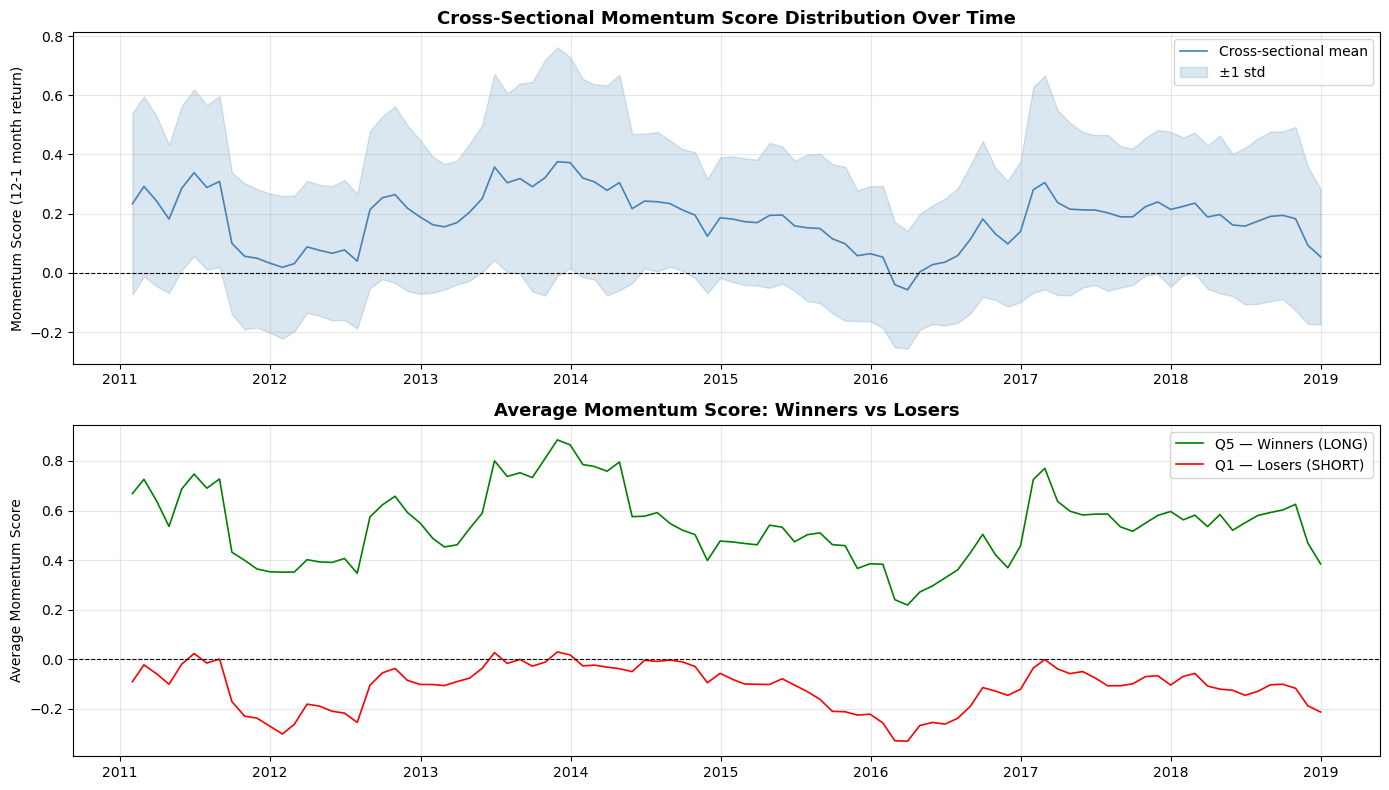

Chart saved to data/momentum_signal_distribution.png


In [53]:
# Compute monthly cross-sectional statistics
monthly_stats = momentum.resample('M').apply(
    lambda df: pd.Series({
        'mean'   : df.stack().mean(),
        'std'    : df.stack().std(),
        'q5_mean': df[quintiles == 5].stack().mean(),
        'q1_mean': df[quintiles == 1].stack().mean(),
    })
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Average momentum score over time
axes[0].plot(monthly_stats.index, monthly_stats['mean'],
             color='steelblue', linewidth=1.2, label='Cross-sectional mean')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].fill_between(monthly_stats.index,
                     monthly_stats['mean'] - monthly_stats['std'],
                     monthly_stats['mean'] + monthly_stats['std'],
                     alpha=0.2, color='steelblue', label='±1 std')
axes[0].set_title('Cross-Sectional Momentum Score Distribution Over Time',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Momentum Score (12-1 month return)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Winner vs Loser average momentum
axes[1].plot(monthly_stats.index, monthly_stats['q5_mean'],
             color='green', linewidth=1.2, label='Q5 — Winners (LONG)')
axes[1].plot(monthly_stats.index, monthly_stats['q1_mean'],
             color='red', linewidth=1.2, label='Q1 — Losers (SHORT)')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Average Momentum Score: Winners vs Losers',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Momentum Score')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/momentum_signal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to data/momentum_signal_distribution.png")

## Signal Visualization — Interpretation

**Chart 1 — Cross-Sectional Mean and Dispersion:**

The cross-sectional mean momentum score remains **persistently positive**
throughout the in-sample period (2011–2018), reflecting the sustained bull
market following the 2008-2009 financial crisis recovery. Two notable
exceptions are visible:

- **2012:** mean briefly approaches zero, corresponding to the European
  sovereign debt crisis and associated market volatility.
- **2016:** mean drops sharply negative, driven by the commodity crash,
  China growth fears, and the brief bear market in early 2016.

The ±1 standard deviation band remains wide throughout (~0.3–0.5),
indicating substantial cross-sectional dispersion — a necessary condition
for a momentum signal to have discriminating power.

**Chart 2 — Winners vs Losers:**

The separation between Q5 (Winners) and Q1 (Losers) is **persistent and
consistent** across the entire in-sample period. Winners maintain average
momentum scores between +0.4 and +0.9, while losers remain between −0.1
and −0.4. This spread of approximately 50–90 percentage points represents
the raw signal strength before any risk adjustment.

The most notable compression occurs in **2016**, when the winner-loser
spread narrows significantly — a known characteristic of momentum strategies,
which tend to underperform during sharp market reversals.